# Программа для обучения 2 моделей для бинарной классификации (обнаружения) акустических сигналов БпЛА

## Подключение библиотек

In [1]:
import os
import glob
import threading

import numpy as np
from numpy.lib.stride_tricks import as_strided
import matplotlib.pyplot as plt

import librosa
import soundfile as sf

from tqdm import tqdm
from datasets import load_dataset, Audio

import tensorflow as tf

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, GlobalAveragePooling1D, Reshape, Subtract, Multiply, Concatenate, Lambda, Dense, Dropout
from tensorflow.keras.layers import Conv2D, SeparableConv2D, MaxPooling2D, GlobalAveragePooling2D, BatchNormalization

from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.metrics import Precision, Recall

from tensorflow.keras.utils import plot_model

from sklearn.model_selection import train_test_split


2026-04-29 21:45:18.895559: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777499119.187012      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777499119.275135      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777499119.976683      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777499119.976816      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777499119.976828      57 computation_placer.cc:177] computation placer alr

## Задание констант

In [2]:
# Объединяем все параметры в структуру Config
class Config:
    # Параметры сессии
    SEED = 52                           # Сид для всех псевдослучайных последовательностей

    # Параметры датасета
    TRAIN_SIZE = 0.85                   # Доля данных для обучения
    VAL_SIZE = 0.15                     # Доля данных для валидации
    TEST_SIZE = 3000                    # Доля данных для тестирования

    # Параметры аудио
    SR = 32000                          # Частота дискретизации
    CHUNK_SEC = 1.0                     # Длина окна анализа
    CHUNK_SAMPLES = int(SR * CHUNK_SEC) # Количество отсчётов в окне

    # Параметры аугментации
    SNR_MIN = -5.0                      # Минимальный SNR при смешивании дрона с шумом
    SNR_MAX = 15.0                      # Максимальный SNR
    GAIN_DB_MIN = -10.0                 # Нижний край случайного усиления (учит инвариантности к громкости)
    GAIN_DB_MAX = 10.0                  # Верхний край

    # Фильтрация чанков по RMS (применяется только к drone-файлам, label==1).
    # Убирает утечку метки на тихих/паузных участках записи.
    MIN_CHUNK_RMS = 1e-3

    # Синтетическая тишина — явный негативный класс
    SILENCE_DIR = "/tmp/dads/silence"
    NUM_SILENCE_FILES = 500             # Сколько штук генерим
    SILENCE_DURATION_SEC = 2.0          # Длительность каждого файла

    # Параметры предобработки данных
    FRAME_LENGTH = 1024                 # Длина окна
    FRAME_STEP = 512                    # Шаг окна (overlap 50%)
    NUM_FRAMES = 61
    FFT_SIZE = 1024                     # Размер окна преобразования Фурье
    FMIN = 0.0                          # Нижняя граница частот
    FMAX = 16000.0                      # Верхняя граница частот
    N_MELS = 96                         # Количество мел-фильтров (повышено для лучшего разрешения нижних гармоник дрона)
    N_MFCC = 20                         # Количество кепстральных коэффициентов (выбрано как компромисс: ловит гармоники дронов, не раздувая 1D-CNN)

    # Параметры обучения
    BATCH_SIZE = 32                     # Размер одной партии данных для обучения
    EPOCHS = 50                         # Количество эпох обучения
    STEPS_PER_EPOCH = 500               # Количество батчей на одну эпоху (увеличено под дополнительные аугментации)
    VAL_STEPS = 50                      # Количество батчей для валидации


## Скачивание внешнего датасета Drone Audio Detection Samples

In [3]:
# Загружаем датасет Drone Audio Detection Samples с Hugging Face
dataset = load_dataset("geronimobasso/drone-audio-detection-samples", split="train")
# Перемешиваем датасет
dataset.shuffle(Config.SEED)

# Выделяем из датасета тестовые файлы
test_split = dataset.train_test_split(test_size=Config.TEST_SIZE, seed=Config.SEED, stratify_by_column="label")
TEST_DS = test_split['test']
remaining_ds = test_split['train']

# Выделяем из датасета данные для обучения и валидации
train_val_split = remaining_ds.train_test_split(test_size=Config.VAL_SIZE, seed=Config.SEED, stratify_by_column="label")
TRAIN_DS = train_val_split['train']
VAL_DS = train_val_split['test']

TRAIN_DS = TRAIN_DS.cast_column("audio", Audio(sampling_rate=Config.SR))
VAL_DS = VAL_DS.cast_column("audio", Audio(sampling_rate=Config.SR))

print(f"Итог разбиения: train = {len(TRAIN_DS)}, validation = {len(VAL_DS)}, test = {len(TEST_DS)}")


README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/39 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/39 [00:00<?, ?it/s]

data/train-00000-of-00039.parquet:   0%|          | 0.00/1.27G [00:00<?, ?B/s]

data/train-00001-of-00039.parquet:   0%|          | 0.00/1.33G [00:00<?, ?B/s]

...

data/train-00036-of-00039.parquet:   0%|          | 0.00/75.0M [00:00<?, ?B/s]

data/train-00037-of-00039.parquet:   0%|          | 0.00/74.9M [00:00<?, ?B/s]

data/train-00038-of-00039.parquet:   0%|          | 0.00/75.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/180320 [00:00<?, ? examples/s]

Итог разбиения: train = 150722, validation = 26598, test = 3000


## Сохранение тестовой выборки Drone Audio Detection Samples

In [4]:
# Функция для сохранения датасета в формате WAV-файлов
def export_dataset_to_wav(dataset, output_dir):
    for i, item in enumerate(tqdm(dataset, desc="Сохранение тестовой выборки")):
        # Получаем свойства аудиофайла из словаря
        audio_array = item['audio']['array']
        orig_sr = item['audio']['sampling_rate']
        label = item['label']

        # Ресемплим до целевой частоты
        if orig_sr != Config.SR:
            audio_array = librosa.resample(y=audio_array, orig_sr=orig_sr, target_sr=Config.SR)

        # Определяем папку назначения
        folder = "drone" if label == 1 else "noise"
        filepath = f"{output_dir}/{folder}/sample_{i}.wav"

        # Сохраняем как WAV-файл
        sf.write(filepath, audio_array, Config.SR, subtype='PCM_16')

# Создаём папки для тестовых данных
test_dir = "/kaggle/working/test"
os.makedirs(f"{test_dir}/noise", exist_ok=True)
os.makedirs(f"{test_dir}/drone", exist_ok=True)

# Сохраняем тестовые данные как WAV-файлы для скачивания
export_dataset_to_wav(TEST_DS, test_dir)

!zip -r -q test_dataset.zip /kaggle/working/test


Сохранение тестовой выборки: 100%|██████████| 3000/3000 [00:59<00:00, 50.03it/s]


## Сохранение обучающей выборки Drone Audio Detection Samples

In [5]:
def dump_dataset_to_disk(hf_dataset, output_dir, desc_text):
    os.makedirs(f"{output_dir}/drone", exist_ok=True)
    os.makedirs(f"{output_dir}/noise", exist_ok=True)

    print(f"\n💾 Сохраняем {desc_text} в {output_dir}...")

    # Используем обычный цикл. Никакого multiprocessing, чтобы избежать SegFault!
    for i, item in enumerate(tqdm(hf_dataset, desc=desc_text)):
        audio = item['audio']['array']
        label = item['label']
        folder = "drone" if label == 1 else "noise"
        filepath = f"{output_dir}/{folder}/{i}.wav"

        # soundfile.write работает на C и сохраняет файл за микросекунды
        sf.write(filepath, audio, Config.SR, subtype='PCM_16')

TRAIN_DIR = "/tmp/dads/train"
VAL_DIR = "/tmp/dads/val"

dump_dataset_to_disk(TRAIN_DS, TRAIN_DIR, "Обучающую выборку (TRAIN)")
dump_dataset_to_disk(VAL_DS, VAL_DIR, "Валидационную выборку (VAL)")



💾 Сохраняем Обучающую выборку (TRAIN) в /tmp/dads/train...


Обучающую выборку (TRAIN): 100%|██████████| 150722/150722 [35:24<00:00, 70.93it/s] 



💾 Сохраняем Валидационную выборку (VAL) в /tmp/dads/val...


Валидационную выборку (VAL): 100%|██████████| 26598/26598 [06:54<00:00, 64.13it/s]


## Функции для предобработки данных

In [6]:
# Копия класса DataPreprocessor из твоего main.py
class DataPreprocessor:
    __slots__ = (
        "cfg", "_window", "_mel_weights", "_dct_matrix",
        "_mfcc_buf", "_mel_buf", "_rms_buf", "_frames_buf", "_spectrum_buf",
    )

    def __init__(self, cfg: Config):
        self.cfg = cfg
        self._window = np.hanning(cfg.FRAME_LENGTH).astype(np.float32)
        self._mel_weights = self._build_mel_filterbank(cfg)
        self._dct_matrix = self._build_dct_matrix(cfg)

        self._mfcc_buf = np.empty((1, cfg.NUM_FRAMES, cfg.N_MFCC), dtype=np.float32)
        self._mel_buf = np.empty((1, cfg.NUM_FRAMES, cfg.N_MELS, 1), dtype=np.float32)
        # log-RMS чанка как доп.вход 1D-CNN: возвращает сети абсолютный уровень
        # сигнала, который MFCC отбрасывают через DCT (а random_gain делает
        # MFCC[0] неинформативным).
        self._rms_buf = np.empty((1, 1), dtype=np.float32)
        self._frames_buf = np.empty((cfg.NUM_FRAMES, cfg.FRAME_LENGTH), dtype=np.float32)
        self._spectrum_buf = np.empty((cfg.NUM_FRAMES, cfg.FFT_SIZE // 2 + 1), dtype=np.float32)

    @staticmethod
    def _build_mel_filterbank(cfg: Config) -> np.ndarray:
        hz_to_mel = lambda hz: 2595.0 * np.log10(1.0 + hz / 700.0)
        mel_to_hz = lambda mel: 700.0 * (10.0 ** (mel / 2595.0) - 1.0)
        num_bins = cfg.FFT_SIZE // 2 + 1
        mel_points = np.linspace(hz_to_mel(cfg.FMIN), hz_to_mel(cfg.FMAX), cfg.N_MELS + 2)
        hz_points = mel_to_hz(mel_points)
        bins = np.floor((cfg.FFT_SIZE + 1) * hz_points / cfg.SR).astype(int)

        filters = np.zeros((num_bins, cfg.N_MELS), dtype=np.float32)
        for i in range(cfg.N_MELS):
            left, center, right = bins[i], bins[i + 1], bins[i + 2]
            if center > left: filters[left:center, i] = np.arange(center - left) / (center - left)
            if right > center: filters[center:right, i] = np.arange(right - center, 0, -1) / (right - center)
        return filters

    @staticmethod
    def _build_dct_matrix(cfg: Config) -> np.ndarray:
        n = np.arange(cfg.N_MELS)
        k = np.arange(cfg.N_MFCC)
        dct = np.cos(np.pi * k[np.newaxis, :] * (2 * n[:, np.newaxis] + 1) / (2 * cfg.N_MELS))
        dct *= np.sqrt(2.0 / cfg.N_MELS)
        return dct.astype(np.float32)

    def _frame(self, audio: np.ndarray) -> np.ndarray:
        audio = np.ascontiguousarray(audio)
        byte_step = audio.strides[0]
        return as_strided(audio, shape=(self.cfg.NUM_FRAMES, self.cfg.FRAME_LENGTH),
                          strides=(self.cfg.FRAME_STEP * byte_step, byte_step))

    def preprocess(self, audio: np.ndarray):
        if audio.dtype != np.float32: audio = audio.astype(np.float32, copy=False)
        # log-RMS считаем ДО матричных операций. log compress'ит большой
        # динамический диапазон (1e-5..1.0) в линейный (-5..0), удобный для Dense.
        rms_raw = float(np.sqrt(np.mean(audio * audio)))
        self._rms_buf[0, 0] = np.log(rms_raw + 1e-7)
        np.multiply(self._frame(audio), self._window, out=self._frames_buf)
        rfft_out = np.fft.rfft(self._frames_buf, n=self.cfg.FFT_SIZE)
        np.multiply(rfft_out.real, rfft_out.real, out=self._spectrum_buf)
        self._spectrum_buf += rfft_out.imag * rfft_out.imag
        np.sqrt(self._spectrum_buf, out=self._spectrum_buf)
        mel_view = self._mel_buf[0, :, :, 0]
        np.matmul(self._spectrum_buf, self._mel_weights, out=mel_view)
        mel_view += 1e-6
        np.log(mel_view, out=mel_view)
        np.matmul(mel_view, self._dct_matrix, out=self._mfcc_buf[0])
        return self._mfcc_buf, self._mel_buf, self._rms_buf


# Хранилище для потокобезопасного инстанцирования препроцессора
thread_local_storage = threading.local()

def get_thread_local_preprocessor():
    if not hasattr(thread_local_storage, "preproc"):
        thread_local_storage.preproc = DataPreprocessor(Config)
    return thread_local_storage.preproc

def numpy_preprocess_wrapper(audio_np):
    preproc = get_thread_local_preprocessor()
    mfcc, mel, rms = preproc.preprocess(audio_np)
    # Обязательно возвращаем копии, так как preproc переиспользует память!
    # И берем [0], чтобы убрать размерность батча (которую добавлял DataPreprocessor).
    return mfcc[0].copy(), mel[0].copy(), rms[0].copy()

@tf.function
def mix_noise(signal, noise, target_snr):
    # Считаем RMS полезного сигнала и шума
    rms_signal = tf.sqrt(tf.reduce_mean(tf.square(signal)))
    rms_noise = tf.sqrt(tf.reduce_mean(tf.square(noise)))

    # Избегаем деления на ноль
    rms_noise = tf.maximum(rms_noise, 1e-7)

    # Считаем RMS шума для целевого SNR
    snr_factor = tf.pow(10.0, target_snr / 20.0)
    target_rms_noise = rms_signal / snr_factor

    # Масштабируем шум
    noise_scaled = noise * (target_rms_noise / rms_noise)

    # Смешиваем
    mixed = signal + noise_scaled

    # Минимаксная нормализация
    max_val = tf.reduce_max(tf.abs(mixed))
    mixed_normalized = tf.cond(
        max_val > 0,
        lambda: mixed / max_val,
        lambda: mixed
    )
    return mixed_normalized

# Заменяем старый extract_features на вызов нашей numpy-функции
@tf.function
def extract_features(audio_tensor):
    # tf.numpy_function позволяет вызвать Python/NumPy код внутри TF-графа
    mfcc, mel, rms = tf.numpy_function(
        numpy_preprocess_wrapper,
        [audio_tensor], [tf.float32, tf.float32, tf.float32]
    )
    # Восстанавливаем форму тензоров (tf.numpy_function стирает shape)
    mfcc.set_shape((Config.NUM_FRAMES, Config.N_MFCC))
    mel.set_shape((Config.NUM_FRAMES, Config.N_MELS, 1))
    rms.set_shape((1,))

    return mfcc, mel, rms

# Остальной код augment_and_extract остается без изменений,
# только убираем ручное добавление размерности канала для mels,
# так как наш DataPreprocessor уже отдаёт (frames, mels, 1)

# Speed perturbation = pitch + tempo одновременно. Линейная интерполяция через
# tf.linspace + tf.gather — без librosa. Реалистично имитирует Доплер-сдвиг
# движущегося источника (BPF-гармоники съезжают по частоте).
@tf.function
def pitch_shift(audio, factor):
    n = tf.shape(audio)[0]
    n_f = tf.cast(n, tf.float32)
    new_n = tf.cast(n_f / factor, tf.int32)
    indices = tf.linspace(0.0, n_f - 1.0, new_n)
    floor_idx = tf.cast(indices, tf.int32)
    ceil_idx = tf.minimum(floor_idx + 1, n - 1)
    frac = indices - tf.cast(floor_idx, tf.float32)
    shifted = tf.gather(audio, floor_idx) * (1.0 - frac) + tf.gather(audio, ceil_idx) * frac
    # Trim или pad до исходной длины, чтобы downstream видел фиксированный shape.
    shifted = tf.cond(
        new_n >= n,
        lambda: shifted[:n],
        lambda: tf.concat([shifted, tf.zeros(n - new_n, dtype=tf.float32)], axis=0),
    )
    shifted.set_shape((Config.CHUNK_SAMPLES,))
    return shifted


# Случайный low-pass через FFT с гладким roll-off. Имитирует атмосферное
# поглощение: высокие частоты затухают экспоненциально с расстоянием. Cutoff
# в log-uniform диапазоне покрывает дальности от близкой записи (16 кГц)
# до десятков метров (3 кГц).
@tf.function
def random_lowpass(audio, min_cutoff_hz, max_cutoff_hz):
    n = Config.CHUNK_SAMPLES
    spec = tf.signal.rfft(audio)
    n_bins = tf.shape(spec)[0]
    freqs = tf.cast(tf.range(n_bins), tf.float32) * Config.SR / tf.cast(n, tf.float32)
    log_min = tf.math.log(tf.cast(min_cutoff_hz, tf.float32))
    log_max = tf.math.log(tf.cast(max_cutoff_hz, tf.float32))
    cutoff = tf.exp(tf.random.uniform([], log_min, log_max))
    # Плавный roll-off в exp вместо жёсткого ступенчатого среза — без ringing.
    rolloff_hz = 1000.0
    gain = tf.where(freqs < cutoff, 1.0, tf.exp(-(freqs - cutoff) / rolloff_hz))
    spec_filtered = spec * tf.cast(gain, tf.complex64)
    out = tf.signal.irfft(spec_filtered, fft_length=[n])
    out.set_shape((Config.CHUNK_SAMPLES,))
    return out


@tf.function
def augment_and_extract(target, noise_audio, is_training=True):
    target_audio, label = target

    if is_training:
        result_audio = tf.cond(
            tf.equal(label, 1.0),
            lambda: mix_noise(
                target_audio,
                noise_audio,
                target_snr=tf.random.uniform([], minval=Config.SNR_MIN, maxval=Config.SNR_MAX)
            ),
            lambda: target_audio
        )

        do_pitch = tf.random.uniform([]) < 0.5
        result_audio = tf.cond(
            do_pitch,
            lambda: pitch_shift(result_audio, tf.random.uniform([], 0.95, 1.05)),
            lambda: result_audio,
        )

        do_lp = tf.logical_and(tf.equal(label, 1.0), tf.random.uniform([]) < 0.5)
        result_audio = tf.cond(
            do_lp,
            lambda: random_lowpass(result_audio, 3000.0, 16000.0),
            lambda: result_audio,
        )
    else:
        result_audio = target_audio

    # === КРИТИЧЕСКИЙ ФИКС: УНИВЕРСАЛЬНАЯ НОРМАЛИЗАЦИЯ ===
    # Как в боевом main.py, мы обязаны нормализовать ВСЕ чанки!
    max_val = tf.reduce_max(tf.abs(result_audio))
    result_audio = tf.cond(
        max_val > 1e-5, # Защита от деления на чистый ноль (синтетическую тишину)
        lambda: result_audio / max_val,
        lambda: result_audio
    )

    mfcc, mel_spectrogram, rms = extract_features(result_audio)
    return {"mfcc": mfcc, "mel_spectrogram": mel_spectrogram, "rms": rms}, label
    

## Функции для загрузки данных

In [7]:
def read_wav(file_path):
    path = file_path.decode('utf-8')
    try:
        # soundfile (libsndfile) "всеяден" и прочитает Format 3 без проблем
        audio, sr = sf.read(path, dtype='float32')

        # Если звук стерео - сводим в моно
        if audio.ndim > 1:
            audio = np.mean(audio, axis=1)

        # На всякий случай: если в DEMAND частота не 32кГц, ресемплим на лету
        if sr != Config.SR:
            audio = librosa.resample(y=audio, orig_sr=sr, target_sr=Config.SR)

        return audio.astype(np.float32)
    except Exception as e:
        print(f"\n⚠️ Ошибка чтения файла {path}: {e}. Возвращаем тишину.")
        # Чтобы пайплайн не упал из-за одного битого файла, возвращаем кусок тишины
        return np.zeros(Config.CHUNK_SAMPLES, dtype=np.float32)

# Зацикливание коротких файлов: вместо отбрасывания (pad_end=False терял
# короткие drone-записи) или паддинга нулями (зашумляет распределение —
# модель училась бы «реальный сигнал + тишина -> drone») повторяем содержимое
# np.tile-аналогом до длины CHUNK_SAMPLES.
def _loop_short_audio(audio):
    n = tf.shape(audio)[0]
    target = tf.constant(Config.CHUNK_SAMPLES, dtype=tf.int32)
    # ceil(target / n)
    repeats = (target + n - 1) // n
    looped = tf.tile(audio, [repeats])
    return looped[:target]


# Функция для чтения WAV-файла и нарезки его на чанки
def load_and_chunk_wav(file_path, label):
    audio = tf.numpy_function(read_wav, [file_path], tf.float32)
    audio.set_shape([None])

    # Если файл короче окна — зацикливаем до полного окна. Иначе tf.signal.frame
    # с pad_end=False вернул бы 0 чанков (старое поведение), и короткие
    # drone-записи терялись бы полностью.
    audio = tf.cond(
        tf.shape(audio)[0] < Config.CHUNK_SAMPLES,
        lambda: _loop_short_audio(audio),
        lambda: audio,
    )

    # pad_end=False: не дописываем нули в конец. Иначе хвостовой чанк дрон-файла
    # был бы на 30-90% из нулей и попадал в обучение с меткой 1 — сеть училась бы
    # «zeros -> drone». Файлы длиной кратной CHUNK_SAMPLES // 2 при этом
    # обрабатываются полностью благодаря зацикливанию выше.
    # frame_step = CHUNK_SAMPLES // 2 даёт 50% overlap: фактический объём
    # тренировочных сэмплов удваивается без новых записей. Дрон или короткое
    # шумовое событие может оказаться в любой части окна, что улучшает
    # позиционную инвариантность.
    chunks = tf.signal.frame(
        audio,
        frame_length=Config.CHUNK_SAMPLES,
        frame_step=Config.CHUNK_SAMPLES // 2,
        pad_end=False
    )

    # Для drone-файлов (label==1) дополнительно отбрасываем тихие чанки —
    # это паузы внутри записи, момент до взлёта и т.п. Их нельзя помечать как
    # «дрон», иначе утечка метки. Шумовые файлы пропускаем без фильтра:
    # тихие сэмплы там корректно несут метку 0 и нужны как явный негативный класс
    # (синтетическая тишина из cell 17 идёт по этому же пути).
    def _filter_drone_chunks():
        rms = tf.sqrt(tf.reduce_mean(tf.square(chunks), axis=1))
        return tf.boolean_mask(chunks, rms > Config.MIN_CHUNK_RMS)

    chunks = tf.cond(
        tf.equal(label, 1.0),
        _filter_drone_chunks,
        lambda: chunks
    )

    num_chunks = tf.shape(chunks)[0]
    chunk_ds = tf.data.Dataset.from_tensor_slices(chunks)
    label_ds = tf.data.Dataset.from_tensors(label).repeat(tf.cast(num_chunks, dtype=tf.int64))
    return tf.data.Dataset.zip((chunk_ds, label_ds))

# Поток чанков фиксированной метки. Файлы пере-шафлятся каждую итерацию,
# interleave round-robin'ит чанки из 16 файлов одновременно. Внутри одного потока
# баланс по классам не нужен — все чанки имеют одну и ту же метку.
def _build_class_stream(file_paths, label_value):
    paths_ds = tf.data.Dataset.from_tensor_slices(list(file_paths))
    paths_ds = paths_ds.shuffle(
        buffer_size=len(file_paths),
        reshuffle_each_iteration=True,
    ).repeat()
    return paths_ds.interleave(
        lambda p: load_and_chunk_wav(p, label_value),
        cycle_length=16,
        num_parallel_calls=tf.data.AUTOTUNE,
    )


# Сбор финального tf.data-конвейера. Главный фикс относительно прежней версии:
# раньше interleave давал поток чанков, ВЗВЕШЕННЫЙ по длинам файлов (длинные
# DEMAND-файлы доминировали ~7:1), и class_weight только частично компенсировал
# это на уровне лосса. Теперь sample_from_datasets с весами 0.5/0.5 гарантирует
# баланс на чанк-уровне — class_weight больше не нужен.
def create_dataset_from_wav(drone_files, noise_files, is_training=True):
    if is_training:
        # Два независимых потока. Каждый бесконечный (repeat внутри _build_class_stream).
        drone_ds = _build_class_stream(drone_files, 1.0)
        noise_ds = _build_class_stream(noise_files, 0.0)

        # 50/50 на чанк-уровне, независимо от длин файлов.
        main_ds = tf.data.Dataset.sample_from_datasets(
            [drone_ds, noise_ds],
            weights=[0.5, 0.5],
            stop_on_empty_dataset=False,
        )
        # Дополнительный shuffle убирает локальную регулярность чередования.
        main_ds = main_ds.shuffle(buffer_size=5000, reshuffle_each_iteration=True)

        # Параллельный поток шума для mix_noise (фон под дрон).
        bg_noise_ds = _build_class_stream(noise_files, 0.0).map(
            lambda audio, _label: audio
        )
        bg_noise_ds = bg_noise_ds.shuffle(buffer_size=1000)

        zipped_ds = tf.data.Dataset.zip((main_ds, bg_noise_ds))
    else:
        # Валидация: баланс не нужен — метрики должны отражать реальное
        # распределение валидационной выборки. Идём прежним путём через interleave.
        all_files = list(drone_files) + list(noise_files)
        all_labels = [1.0] * len(drone_files) + [0.0] * len(noise_files)
        rng = np.random.default_rng(Config.SEED)
        order = rng.permutation(len(all_files))
        all_files = [all_files[i] for i in order]
        all_labels = [all_labels[i] for i in order]

        source_ds = tf.data.Dataset.from_tensor_slices((all_files, all_labels))
        main_ds = source_ds.interleave(
            load_and_chunk_wav,
            cycle_length=16,
            num_parallel_calls=tf.data.AUTOTUNE,
        )
        dummy_noise = tf.data.Dataset.from_tensors(
            tf.zeros(Config.CHUNK_SAMPLES, dtype=tf.float32)
        ).repeat()
        zipped_ds = tf.data.Dataset.zip((main_ds, dummy_noise))

    final_ds = zipped_ds.map(
        lambda main_data, bg_noise: augment_and_extract(main_data, bg_noise, is_training),
        num_parallel_calls=tf.data.AUTOTUNE,
    )

    final_ds = final_ds.batch(Config.BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

    if is_training:
        final_ds = final_ds.repeat()

    return final_ds

# Функция для чтения данных из HF-датасета
def dataset_generator(dataset):
    for item in dataset:
        # Получаем свойства аудиофайла из словаря
        audio = item['audio']['array']
        orig_sr = item['audio']['sampling_rate']
        label = item['label']

        # Ресемплим до целевой частоты
        if orig_sr != Config.SR:
            audio = librosa.resample(y=audio, orig_sr=orig_sr, target_sr=Config.SR)

        audio_len = len(audio)

        # Если файл длинный, берем случайный срез
        if audio_len > Config.CHUNK_SAMPLES:
            max_start = audio_len - Config.CHUNK_SAMPLES
            start = np.random.randint(0, max_start)
            audio = audio[start : start + Config.CHUNK_SAMPLES]
        elif audio_len < Config.CHUNK_SAMPLES:
            # Если короткий - зацикливаем содержимое (np.tile), а не паддим нулями.
            # Иначе короткий drone-файл превращался бы в «короткий сигнал + тишина»,
            # что ломает распределение MFCC/RMS относительно нормальных секунд.
            repeats = (Config.CHUNK_SAMPLES + audio_len - 1) // audio_len
            audio = np.tile(audio, repeats)[: Config.CHUNK_SAMPLES]

        # Возвращаем чистые numpy-объекты. Теперь ошибки EagerTensor не будет!
        yield audio, np.float32(label)

# Функция для создания датасета из HF-датасета
def create_dataset_from_hf(dataset, is_training=True):
    main_ds = tf.data.Dataset.from_generator(
        lambda: dataset_generator(dataset),
        output_signature=(
            tf.TensorSpec(shape=(Config.CHUNK_SAMPLES,), dtype=tf.float32),
            tf.TensorSpec(shape=(), dtype=tf.float32)
        )
    )

     # 2. Создаем поток фонового шума для аугментации
    if is_training:
        noise_subset = dataset.filter(lambda x: x['label'] == 0)

        bg_noise_ds = tf.data.Dataset.from_generator(
            lambda: dataset_generator(noise_subset),
            output_signature=(
                tf.TensorSpec(shape=(Config.CHUNK_SAMPLES,), dtype=tf.float32),
                tf.TensorSpec(shape=(), dtype=tf.float32)
            )
        ).map(lambda audio, label: audio) # Отбрасываем метку, оставляем только звук

        # Делаем поток бесконечным и перемешиваем
        bg_noise_ds = bg_noise_ds.shuffle(buffer_size=1000).repeat()

        # Сшиваем основной поток и поток шумов
        zipped_ds = tf.data.Dataset.zip((main_ds, bg_noise_ds))
    else:
        # Для валидации создаем бесконечный генератор нулей (пустышку)
        dummy_noise = tf.data.Dataset.from_tensors(tf.zeros(Config.CHUNK_SAMPLES, dtype=tf.float32)).repeat()
        zipped_ds = tf.data.Dataset.zip((main_ds, dummy_noise))

    # 3. Применяем аугментацию и извлекаем признаки
    # Используем lambda, чтобы передать флаг is_training
    final_ds = zipped_ds.map(
        lambda target, noise: augment_and_extract(target, noise, is_training=is_training),
        num_parallel_calls=tf.data.AUTOTUNE
    )

    # 4. Батчинг и перемешивание
    if is_training:
        final_ds = final_ds.shuffle(buffer_size=5000, reshuffle_each_iteration=True)

    final_ds = final_ds.batch(Config.BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

    # Делаем поток бесконечным для тренировочной выборки,
    # чтобы вручную контролировать длину эпохи через steps_per_epoch
    if is_training:
        final_ds = final_ds.repeat()

    return final_ds


## Непосредственная подготовка данных для обучения

In [8]:
train_drones = glob.glob(f"{TRAIN_DIR}/drone/*.wav")
train_noises = glob.glob(f"{TRAIN_DIR}/noise/*.wav")
val_drones = glob.glob(f"{VAL_DIR}/drone/*.wav")
val_noises = glob.glob(f"{VAL_DIR}/noise/*.wav")

demand_path = "/kaggle/input/demand-noise-for-drone-detection/DEMAND_noise_for_drone"
# glob.glob с флагом recursive=True найдет все .wav файлы во всех подпапках
demand_noise_files = glob.glob(f"{demand_path}/**/*.wav", recursive=True)

train_noises.extend(demand_noise_files)

microphone_path = "/kaggle/input/datasets/shmlvssh/mircophone-dataset-for-drone-detection/MircophoneDataSet"

microphone_drone_files = glob.glob(f"{microphone_path}/drone/*.wav")
microphone_noise_files = glob.glob(f"{microphone_path}/noise/*.wav")

train_drones.extend(microphone_drone_files)
train_noises.extend(microphone_noise_files)

# Синтетическая тишина — явный негативный класс ----------------------------
# Без этого сеть классифицирует тишину как «дрон»: peak-нормализация в инференсе
# усиливает мик-флор до уровня сигнала, а в обучении модель такого распределения
# не видела. Sigma в логарифмически равномерном диапазоне 1e-5..1e-2 покрывает
# всё от АЦП-молчания до тихого помещения.
print("\n🔇 Генерируем синтетическую тишину...")
os.makedirs(Config.SILENCE_DIR, exist_ok=True)
_silence_rng = np.random.default_rng(Config.SEED)
_n_silence_samples = int(Config.SILENCE_DURATION_SEC * Config.SR)
for _i in tqdm(range(Config.NUM_SILENCE_FILES), desc="Silence"):
    _sigma = 10 ** _silence_rng.uniform(-5, -2)
    _audio = (_silence_rng.standard_normal(_n_silence_samples) * _sigma).astype(np.float32)
    sf.write(f"{Config.SILENCE_DIR}/silence_{_i:04d}.wav", _audio, Config.SR, subtype="PCM_16")

silence_files = glob.glob(f"{Config.SILENCE_DIR}/*.wav")
train_noises.extend(silence_files)
print(f"✅ Добавлено {len(silence_files)} файлов синтетической тишины в train_noises")

# Считаем чанки чисто для информационного вывода — class_weight больше не считаем,
# т.к. balanced sampling в create_dataset_from_wav сам обеспечивает 50/50 на батче.
def count_total_chunks(file_paths):
    total_chunks = 0
    for path in file_paths:
        try:
            info = sf.info(path)
            # pad_end=False: файлы короче CHUNK_SAMPLES не дают ни одного чанка.
            # RMS-фильтр для drone-файлов отрежет ещё какую-то долю — но точно
            # предсказать без чтения файла нельзя, поэтому считаем верхнюю оценку.
            total_chunks += int(info.frames // Config.CHUNK_SAMPLES)
        except Exception:
            pass
    return total_chunks

print("\n⏳ Анализируем продолжительность файлов...")
chunks_drone_train = count_total_chunks(train_drones)
chunks_noise_train = count_total_chunks(train_noises)
print(f"📊 Чанков в TRAIN (без overlap): Дронов = {chunks_drone_train}, Шума = {chunks_noise_train}")
print(f"   Дисбаланс по чанкам: {chunks_noise_train / max(chunks_drone_train, 1):.1f}x в пользу шума.")
print(f"   Без балансировки доля дронов в батче была бы ~{100 * chunks_drone_train / (chunks_drone_train + chunks_noise_train):.1f}%.")
print(f"   sample_from_datasets компенсирует это до 50/50 на чанк-уровне.")

print("\n⚙️ Сборка конвейеров tf.data...")
train_dataset = create_dataset_from_wav(train_drones, train_noises, is_training=True)
val_dataset = create_dataset_from_wav(val_drones, val_noises, is_training=False)

print("✅ Датасеты готовы к подаче в нейросеть!")


🔇 Генерируем синтетическую тишину...


Silence: 100%|██████████| 500/500 [00:05<00:00, 97.72it/s] 


✅ Добавлено 500 файлов синтетической тишины в train_noises

⏳ Анализируем продолжительность файлов...
📊 Чанков в TRAIN (без overlap): Дронов = 13101, Шума = 101977
   Дисбаланс по чанкам: 7.8x в пользу шума.
   Без балансировки доля дронов в батче была бы ~11.4%.
   sample_from_datasets компенсирует это до 50/50 на чанк-уровне.

⚙️ Сборка конвейеров tf.data...


2026-04-29 22:49:41.493398: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


✅ Датасеты готовы к подаче в нейросеть!


## Создание 1D-CNN модели

In [11]:
# Stats pooling: concat [mean, std] по оси времени. Std даёт сети feature
# стационарности — стационарный гул дрона имеет низкий std, импульсные FP
# (хлопок, лай) — высокий. GAP в одиночку этого не различает.
def _stats_pool_1d(x):
    # 1. Вычисляем среднее по времени: shape (batch, channels)
    mean = GlobalAveragePooling1D()(x) 
    # 2. Добавляем временную ось для broadcasting: shape (batch, 1, channels)
    mean_expanded = Reshape((1, -1))(mean)
    # 3. Вычисляем (X - mean)^2
    diff = Subtract()([x, mean_expanded])
    sq_diff = Multiply()([diff, diff])
    # 4. Дисперсия как E[(X - mean)^2]: shape (batch, channels)
    var = GlobalAveragePooling1D()(sq_diff)
    # 5. Стандартное отклонение с защитой от нуля
    std = Lambda(lambda t: tf.sqrt(tf.maximum(t, 1e-6)))(var)
    
    return Concatenate(axis=-1)([mean, std])


def build_model_1d(input_shape):
    # MFCC-вход: основной сигнал — форма спектра во времени.
    mfcc_input = Input(shape=input_shape, name="mfcc")

    # 1-й блок: Базовые паттерны
    x = Conv1D(filters=32, kernel_size=3, padding='same')(mfcc_input)
    x = BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)
    x = MaxPooling1D(pool_size=2)(x)

    # 2-й блок: Среднеуровневые признаки
    x = Conv1D(filters=64, kernel_size=3, padding='same')(x)
    x = BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)
    x = MaxPooling1D(pool_size=2)(x)

    # 3-й блок: Глубокие акустические структуры
    x = Conv1D(filters=128, kernel_size=3, padding='same')(x)
    x = BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)

    # Stats pooling: [mean, std] по времени.
    x = _stats_pool_1d(x)

    # RMS-вход: вспомогательный скаляр (log-RMS чанка) — даёт сети информацию
    # о соотношении пик/RMS (форма сигнала) после peak-normalize.
    rms_input = Input(shape=(1,), name="rms")
    rms_features = Dense(8, activation='relu', name="rms_features")(rms_input)

    # Слияние спектральной и уровневой ветвей.
    combined = tf.keras.layers.Concatenate(axis=-1)([x, rms_features])
    combined = Dropout(0.3)(combined)

    outputs = Dense(1, activation='sigmoid', name="output_prob")(combined)

    model = Model(inputs=[mfcc_input, rms_input], outputs=outputs, name="1D_CNN")
    return model

# 1. Вычисляем размерность входа
# На 1 секунду при SR=32000, окне 1024 и шаге 512 получается 61 фрейм.
mfcc_frames = (Config.CHUNK_SAMPLES - Config.FRAME_LENGTH) // Config.FRAME_STEP + 1
input_shape_1d = (mfcc_frames, Config.N_MFCC)

print(input_shape_1d)

# 2. Создаем и компилируем модель
model_1d = build_model_1d(input_shape_1d)

model_1d.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='binary_crossentropy',
    metrics=['accuracy', Precision(name='precision'), Recall(name='recall')]
)

model_1d.summary()


(61, 20)


Model: "1D_CNN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ mfcc (InputLayer)   │ (None, 61, 20)    │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_6 (Conv1D)   │ (None, 61, 32)    │      1,952 │ mfcc[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 61, 32)    │        128 │ conv1d_6[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_6 (ReLU)      │ (None, 61, 32)    │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_4     │ (None, 30, 32)    │          0 │ re_lu_6[0][0]     │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_7 (Conv1D)   │ (None, 30, 64)    │      6,208 │ max_pooling1d_4[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 30, 64)    │        256 │ conv1d_7[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_7 (ReLU)      │ (None, 30, 64)    │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_5     │ (None, 15, 64)    │          0 │ re_lu_7[0][0]     │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_8 (Conv1D)   │ (None, 15, 128)   │     24,704 │ max_pooling1d_5[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 15, 128)   │        512 │ conv1d_8[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_8 (ReLU)      │ (None, 15, 128)   │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ re_lu_8[0][0]     │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_2 (Reshape) │ (None, 1, 128)    │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ subtract_2          │ (None, 15, 128)   │          0 │ re_lu_8[0][0],    │
│ (Subtract)          │                   │            │ reshape_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_2          │ (None, 15, 128)   │          0 │ subtract_2[0][0], │
│ (Multiply)          │                   │            │ subtract_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ multiply_2[0][0]  │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_2 (Lambda)   │ (None, 128)       │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rms (InputLayer)    │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_4       │ (None, 256)       │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ lambda_2[0][0]  

 Total params: 34,041 (132.97 KB)

 Trainable params: 33,593 (131.22 KB)

 Non-trainable params: 448 (1.75 KB)

## Обучение 1D-CNN модели

In [12]:
# 3. Настройка коллбеков (автоматическое сохранение лучшей модели и остановка)
callbacks_1d =[
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ModelCheckpoint('1d_cnn.keras', monitor='val_loss', save_best_only=True, verbose=0)
]

train_dataset_1d = train_dataset.map(
    lambda features, label: ({"mfcc": features["mfcc"], "rms": features["rms"]}, label),
    num_parallel_calls=tf.data.AUTOTUNE
)
val_dataset_1d = val_dataset.map(
    lambda features, label: ({"mfcc": features["mfcc"], "rms": features["rms"]}, label),
    num_parallel_calls=tf.data.AUTOTUNE
)

history_1d = model_1d.fit(
    train_dataset_1d,
    validation_data=val_dataset_1d,
    epochs=Config.EPOCHS,
    callbacks=callbacks_1d,
    steps_per_epoch=Config.STEPS_PER_EPOCH,
)


Epoch 1/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step - accuracy: 0.8908 - loss: 0.2628 - precision: 0.9031 - recall: 0.8811

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


500/500 ━━━━━━━━━━━━━━━━━━━━ 475s 897ms/step - accuracy: 0.8909 - loss: 0.2627 - precision: 0.9032 - recall: 0.8811 - val_accuracy: 0.9016 - val_loss: 0.2349 - val_precision: 0.9421 - val_recall: 0.8416
Epoch 2/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 467s 936ms/step - accuracy: 0.9546 - loss: 0.1339 - precision: 0.9702 - recall: 0.9384 - val_accuracy: 0.9101 - val_loss: 0.2451 - val_precision: 0.9668 - val_recall: 0.8368
Epoch 3/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 453s 909ms/step - accuracy: 0.9452 - loss: 0.1512 - precision: 0.9671 - recall: 0.9209 - val_accuracy: 0.9110 - val_loss: 0.2225 - val_precision: 0.9591 - val_recall: 0.8461
Epoch 4/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 433s 867ms/step - accuracy: 0.9693 - loss: 0.0961 - precision: 0.9849 - recall: 0.9539 - val_accuracy: 0.9275 - val_loss: 0.2104 - val_precision: 0.9821 - val_recall: 0.8608
Epoch 5/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 448s 898ms/step - accuracy: 0.9550 - loss: 0.1216 - precision: 0.9739 - recall: 0.9341 - val_accuracy: 0.9140 - val

## Создание 2D-CNN модели

In [13]:
# Аналог _stats_pool_1d, но для 2D-карт признаков.
def _stats_pool_2d(x):
    # 1. Среднее по пространству: shape (batch, channels)
    mean = GlobalAveragePooling2D()(x)
    # 2. Добавляем пространственные оси: shape (batch, 1, 1, channels)
    mean_expanded = Reshape((1, 1, -1))(mean)
    # 3. Вычисляем (X - mean)^2
    diff = Subtract()([x, mean_expanded])
    sq_diff = Multiply()([diff, diff])
    # 4. Дисперсия
    var = GlobalAveragePooling2D()(sq_diff)
    # 5. Стандартное отклонение
    std = Lambda(lambda t: tf.sqrt(tf.maximum(t, 1e-6)))(var)
    
    return Concatenate(axis=-1)([mean, std])

def build_model_2d(input_shape):
    inputs = Input(shape=input_shape, name="mel_spectrogram")

    # 1. Первый слой - обычная свертка
    x = Conv2D(32, kernel_size=(3, 3), padding='same', use_bias=False)(inputs)
    x = BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)

    # 2. Блок 1 (Сепарабельный)
    x = SeparableConv2D(64, kernel_size=(3, 3), padding='same', use_bias=False)(x)
    x = BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)

    # 3. Блок 2 (Сепарабельный)
    x = SeparableConv2D(128, kernel_size=(3, 3), padding='same', use_bias=False)(x)
    x = BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)

    # 4. Блок 3 (глубокий)
    x = SeparableConv2D(256, kernel_size=(3, 3), padding='same', use_bias=False)(x)
    x = BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)

    # Stats pooling: [mean, std] по пространственным осям.
    x = _stats_pool_2d(x)

    x = Dropout(0.3)(x)

    outputs = Dense(1, activation='sigmoid', name="output_prob")(x)

    model = Model(inputs=inputs, outputs=outputs, name="2D_CNN")
    return model


# 1. Вычисляем размерность входа
# Добавляем "1" в конце, так как Мел-спектрограмма - это одноканальное изображение (Grayscale)
input_shape_2d = (mfcc_frames, Config.N_MELS, 1)

print(input_shape_2d)

# 2. Создаем и компилируем модель
model_2d = build_model_2d(input_shape_2d)

# Для второй модели мы можем использовать чуть меньший learning rate
model_2d.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='binary_crossentropy',
    metrics=['accuracy', Precision(name='precision'), Recall(name='recall')]
)

model_2d.summary()


(61, 96, 1)


Model: "2D_CNN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ mel_spectrogram     │ (None, 61, 96, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 61, 96,    │        288 │ mel_spectrogram[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 61, 96,    │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_9 (ReLU)      │ (None, 61, 96,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 30, 48,    │          0 │ re_lu_9[0][0]     │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d    │ (None, 30, 48,    │      2,336 │ max_pooling2d[0]… │
│ (SeparableConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 30, 48,    │        256 │ separable_conv2d… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_10 (ReLU)     │ (None, 30, 48,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 15, 24,    │          0 │ re_lu_10[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_1  │ (None, 15, 24,    │      8,768 │ max_pooling2d_1[… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 15, 24,    │        512 │ separable_conv2d… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_11 (ReLU)     │ (None, 15, 24,    │          0 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 7, 12,     │          0 │ re_lu_11[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_2  │ (None, 7, 12,     │     33,920 │ max_pooling2d_2[… │
│ (SeparableConv2D)   │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 7, 12,     │      1,024 │ separable_conv2d… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_12 (ReLU)     │ (None, 7, 12,     │          0 │ batch_normalizat… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 256)       │          0 │ re_lu_12[0][0]  

 Total params: 47,745 (186.50 KB)

 Trainable params: 46,785 (182.75 KB)

 Non-trainable params: 960 (3.75 KB)

## Обучение 2D-CNN модели

In [14]:
# 3. Настройка коллбеков
callbacks_2d =[
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ModelCheckpoint('2d_cnn.keras', monitor='val_loss', save_best_only=True, verbose=0)
]

train_dataset_2d = train_dataset.map(
    lambda features, label: (features["mel_spectrogram"], label),
    num_parallel_calls=tf.data.AUTOTUNE
)
val_dataset_2d = val_dataset.map(
    lambda features, label: (features["mel_spectrogram"], label),
    num_parallel_calls=tf.data.AUTOTUNE
)

history_2d = model_2d.fit(
    train_dataset_2d,
    validation_data=val_dataset_2d,
    epochs=Config.EPOCHS,
    callbacks=callbacks_2d,
    steps_per_epoch=Config.STEPS_PER_EPOCH,
)


Epoch 1/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 681s 1s/step - accuracy: 0.9019 - loss: 0.2387 - precision: 0.9056 - recall: 0.9068 - val_accuracy: 0.8431 - val_loss: 0.3331 - val_precision: 0.7866 - val_recall: 0.9128
Epoch 2/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 653s 1s/step - accuracy: 0.9455 - loss: 0.1484 - precision: 0.9625 - recall: 0.9256 - val_accuracy: 0.9328 - val_loss: 0.2506 - val_precision: 0.9957 - val_recall: 0.8601
Epoch 3/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 688s 1s/step - accuracy: 0.9656 - loss: 0.0998 - precision: 0.9793 - recall: 0.9510 - val_accuracy: 0.9512 - val_loss: 0.1623 - val_precision: 0.9889 - val_recall: 0.9059
Epoch 4/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 682s 1s/step - accuracy: 0.9549 - loss: 0.1219 - precision: 0.9714 - recall: 0.9371 - val_accuracy: 0.9498 - val_loss: 0.1568 - val_precision: 0.9910 - val_recall: 0.9009
Epoch 5/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 652s 1s/step - accuracy: 0.9599 - loss: 0.1047 - precision: 0.9727 - recall: 0.9451 - val_accuracy: 0.9364 - val_los

## Добавление слоя с предобработкой данных в сами модели

In [15]:
def representative_dataset_1d():
    # 1D-CNN двухвходовая (mfcc + rms). Передаём список в порядке model.inputs;
    # dict здесь молча ломает калибровку INT8.
    for features, _ in train_dataset.unbatch().take(500):
        yield [
            tf.expand_dims(features["mfcc"], 0),
            tf.expand_dims(features["rms"], 0),
        ]

def representative_dataset_2d():
    for features, _ in train_dataset.unbatch().take(500):
        # Добавляем размерность батча -> (1, NUM_FRAMES, N_MELS, 1)
        yield [tf.expand_dims(features["mel_spectrogram"], 0)]

def _print_tflite_io(model_path):
    """Выводит схему входов/выходов TFLite-модели для верификации.

    Критично для 1D-модели: app/main.py ищет индексы входов по подстрокам
    'mfcc' и 'rms' в имени тензора. Если конвертер потерял имена или
    модель оказалась одновходовой — main.py упадёт на StopIteration
    в next(d for d in details if "mfcc" in d["name"]).
    """
    interp = tf.lite.Interpreter(model_path=model_path)
    interp.allocate_tensors()
    in_details = interp.get_input_details()
    out_details = interp.get_output_details()

    print(f"   ── TFLite I/O для {model_path} ──")
    print(f"   Входов: {len(in_details)}")
    for d in in_details:
        print(
            f"     [{d['index']}] name='{d['name']}' "
            f"shape={tuple(d['shape'])} dtype={np.dtype(d['dtype']).name}"
        )
    print(f"   Выходов: {len(out_details)}")
    for d in out_details:
        print(
            f"     [{d['index']}] name='{d['name']}' "
            f"shape={tuple(d['shape'])} dtype={np.dtype(d['dtype']).name}"
        )

    # Sanity-check для 1D-модели: ровно 2 входа, имена содержат 'mfcc' и 'rms'.
    if "1d" in model_path.lower():
        names = [d["name"].lower() for d in in_details]
        has_mfcc = any("mfcc" in n for n in names)
        has_rms = any("rms" in n for n in names)
        if len(in_details) == 2 and has_mfcc and has_rms:
            print("   ✅ 1D-модель: 2 входа (mfcc + rms) определены корректно.")
        else:
            print(
                f"   ❌ ВНИМАНИЕ: ожидались 2 входа с именами 'mfcc' и 'rms', "
                f"получено {len(in_details)}: {names}. "
                f"app/main.py не сможет найти тензоры по подстрокам!"
            )


def convert_pure_cnn_int8(concrete_fn, rep_gen, output_filename):
    print(f"⏳ Конвертация {output_filename}...")
    converter = tf.lite.TFLiteConverter.from_concrete_functions([concrete_fn])

    # Только стандартные операции TFLite (работает ВЕЗДЕ!)
    converter.target_spec.supported_ops = [
        tf.lite.OpsSet.TFLITE_BUILTINS_INT8,
        tf.lite.OpsSet.TFLITE_BUILTINS
    ]

    # Квантование
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.representative_dataset = rep_gen

    # Полное INT8 квантование
    converter.target_spec.supported_types = [tf.int8]
    converter.inference_input_type = tf.float32
    converter.inference_output_type = tf.float32

    tflite_model = converter.convert()

    with open(output_filename, 'wb') as f:
        f.write(tflite_model)
    print(f"✅ Сохранено: {output_filename} (Размер: {os.path.getsize(output_filename)/1024:.2f} KB)")

    # Верификация: распечатать схему входов/выходов готового .tflite.
    _print_tflite_io(output_filename)


# Concrete function с двумя именованными позиционными входами для 1D-CNN.
# Имена 'mfcc' и 'rms' сохраняются в TFLite-сигнатуре, по ним main.py ищет
# индексы тензоров (next(d for d in details if "mfcc" in d["name"])).
@tf.function(input_signature=[
    tf.TensorSpec(shape=[1, Config.NUM_FRAMES, Config.N_MFCC], dtype=tf.float32, name='mfcc'),
    tf.TensorSpec(shape=[1, 1], dtype=tf.float32, name='rms'),
])
def serve_1d(mfcc, rms):
    return model_1d([mfcc, rms])

# Для 2D вход один, но используем тот же путь через concrete function ради
# единообразия и чтобы зафиксировать batch=1 в сигнатуре.
@tf.function(input_signature=[
    tf.TensorSpec(shape=[1, Config.NUM_FRAMES, Config.N_MELS, 1], dtype=tf.float32, name='mel_spectrogram'),
])
def serve_2d(mel_spectrogram):
    return model_2d(mel_spectrogram)

# 3. Запуск
convert_pure_cnn_int8(serve_1d.get_concrete_function(), representative_dataset_1d, "model_1d.tflite")
convert_pure_cnn_int8(serve_2d.get_concrete_function(), representative_dataset_2d, "model_2d.tflite")

⏳ Конвертация model_1d.tflite...


I0000 00:00:1777519560.110506      57 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 0
I0000 00:00:1777519560.122131      57 single_machine.cc:374] Starting new session
/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:854: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
W0000 00:00:1777519560.485882      57 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1777519560.485939      57 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
fully_quantize: 0, inference_type: 6, input_inference_type: FLOAT32, output_inference_type: FLOAT32
/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.go

✅ Сохранено: model_1d.tflite (Размер: 46.12 KB)
   ── TFLite I/O для model_1d.tflite ──
   Входов: 2
     [0] name='mfcc' shape=(np.int32(1), np.int32(61), np.int32(20)) dtype=float32
     [1] name='rms' shape=(np.int32(1), np.int32(1)) dtype=float32
   Выходов: 1
     [39] name='Identity' shape=(np.int32(1), np.int32(1)) dtype=float32
   ✅ 1D-модель: 2 входа (mfcc + rms) определены корректно.
⏳ Конвертация model_2d.tflite...


I0000 00:00:1777519582.035363      57 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 0
I0000 00:00:1777519582.035575      57 single_machine.cc:374] Starting new session
W0000 00:00:1777519582.242646      57 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1777519582.242696      57 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.


✅ Сохранено: model_2d.tflite (Размер: 71.63 KB)
   ── TFLite I/O для model_2d.tflite ──
   Входов: 1
     [0] name='mel_spectrogram' shape=(np.int32(1), np.int32(61), np.int32(96), np.int32(1)) dtype=float32
   Выходов: 1
     [42] name='Identity' shape=(np.int32(1), np.int32(1)) dtype=float32


fully_quantize: 0, inference_type: 6, input_inference_type: FLOAT32, output_inference_type: FLOAT32


📈 Визуализация результатов для 1D-CNN


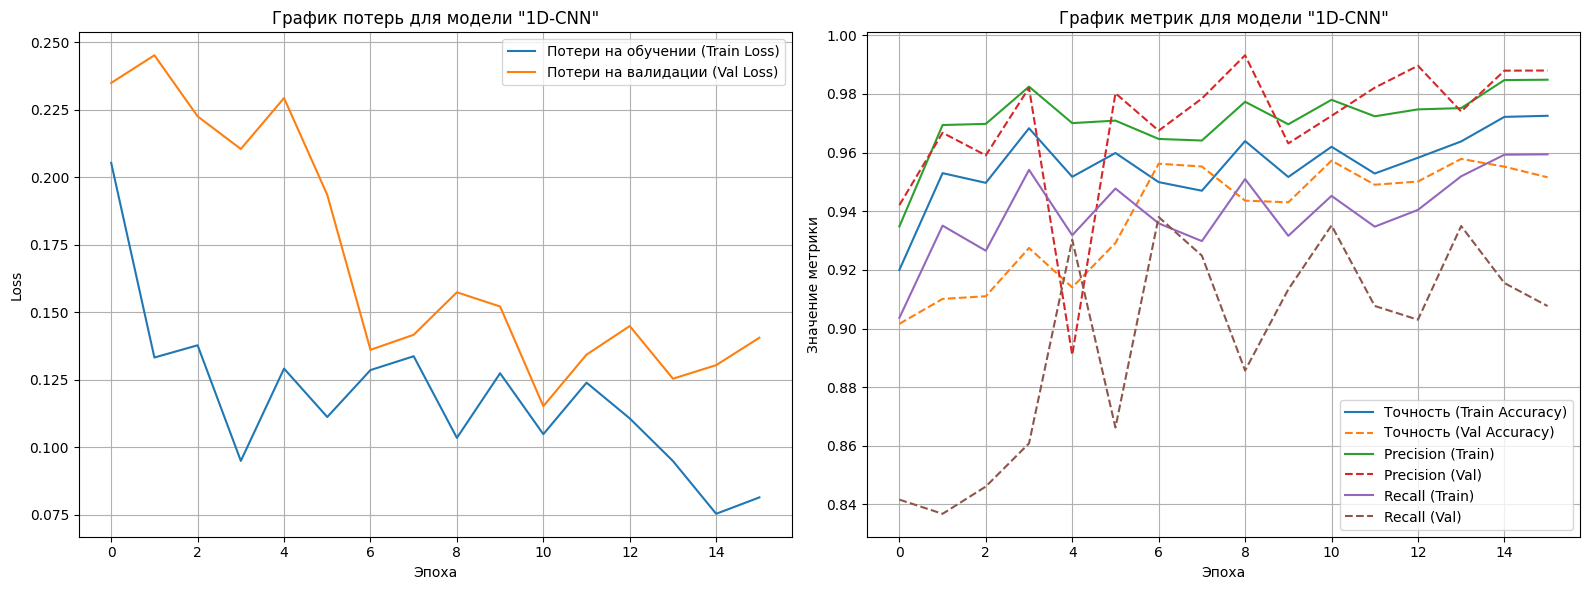


📈 Визуализация результатов для 2D-CNN


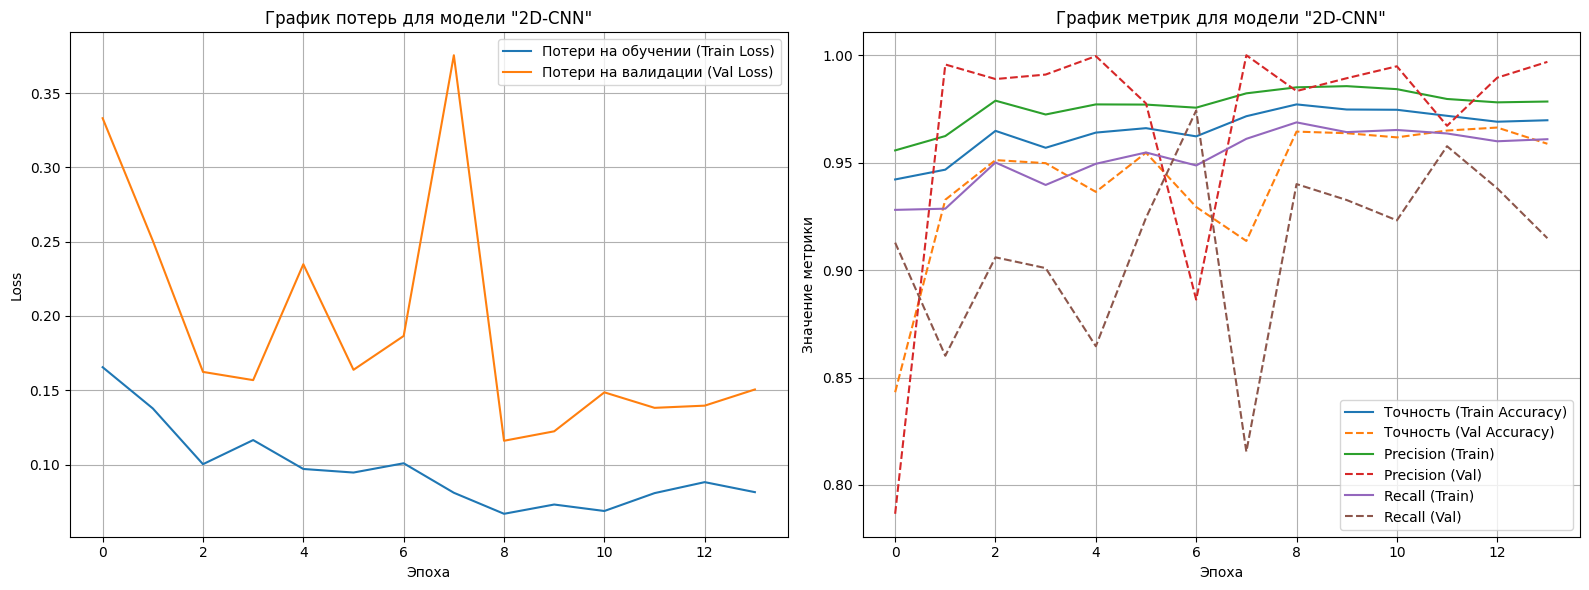


✅ Схема архитектуры Модели 1 сохранена в 'architecture_1d_cnn.png'
✅ Схема архитектуры Модели 2 сохранена в 'architecture_2d_cnn.png'


In [16]:
# ==========================================
# БЛОК 6: ОЦЕНКА РЕЗУЛЬТАТОВ И ВИЗУАЛИЗАЦИЯ
# ==========================================

# ---------------------------------------------------------
# 6.1: Функция для построения графиков обучения
# ---------------------------------------------------------
def plot_learning_curves(history, model_name):
    """
    Принимает объект history от model.fit() и строит графики.
    """
    # Создаем область для двух графиков рядом
    plt.figure(figsize=(16, 6))

    # --- График 1: Потери (Loss) ---
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Потери на обучении (Train Loss)')
    plt.plot(history.history['val_loss'], label='Потери на валидации (Val Loss)')
    plt.title(f'График потерь для модели "{model_name}"')
    plt.xlabel('Эпоха')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    # --- График 2: Метрики (Accuracy, Precision, Recall) ---
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Точность (Train Accuracy)')
    plt.plot(history.history['val_accuracy'], label='Точность (Val Accuracy)', linestyle='--')
    plt.plot(history.history['precision'], label='Precision (Train)')
    plt.plot(history.history['val_precision'], label='Precision (Val)', linestyle='--')
    plt.plot(history.history['recall'], label='Recall (Train)')
    plt.plot(history.history['val_recall'], label='Recall (Val)', linestyle='--')
    plt.title(f'График метрик для модели "{model_name}"')
    plt.xlabel('Эпоха')
    plt.ylabel('Значение метрики')
    plt.legend()
    plt.grid(True)

    plt.tight_layout() # Чтобы графики не наезжали друг на друга
    plt.show()

# ---------------------------------------------------------
# 6.2: Вызов функций для обеих моделей
# ---------------------------------------------------------
# ВНИМАНИЕ: Если ты перезапустил ноутбук, убедись, что переменные
# history_1d и history_2d существуют после обучения!
if 'history_1d' in locals():
    print("📈 Визуализация результатов для 1D-CNN")
    plot_learning_curves(history_1d, "1D-CNN")
else:
    print("⚠️ Объект history_1d не найден. Пропустили обучение Модели 1.")

if 'history_2d' in locals():
    print("\n📈 Визуализация результатов для 2D-CNN")
    plot_learning_curves(history_2d, "2D-CNN")
else:
    print("⚠️ Объект history_2d не найден. Пропустили обучение Модели 2.")

# ---------------------------------------------------------
# 6.3: Визуализация архитектуры моделей (Графы)
# ---------------------------------------------------------
# Эта функция сохранит схемы моделей в виде PNG файлов прямо в Kaggle.
# Эти картинки ты сможешь скачать и вставить в свою диссертацию.

try:
    # Граф для 1D-CNN
    plot_model(
        model_1d,
        to_file='architecture_1d_cnn.png',
        show_shapes=True, # Обязательно показываем размерности тензоров!
        show_layer_names=True,
        rankdir='TB' # Вертикальная ориентация (Top-to-Bottom)
    )
    print("\n✅ Схема архитектуры Модели 1 сохранена в 'architecture_1d_cnn.png'")

    # Граф для 2D-CNN
    plot_model(
        model_2d,
        to_file='architecture_2d_cnn.png',
        show_shapes=True,
        show_layer_names=True,
        rankdir='TB'
    )
    print("✅ Схема архитектуры Модели 2 сохранена в 'architecture_2d_cnn.png'")

except Exception as e:
    print(f"\n❌ Не удалось сгенерировать схемы. Возможно, нужно установить 'pydot' и 'graphviz'.")
    print(f"Попробуйте выполнить в ячейке: !pip install pydot graphviz")